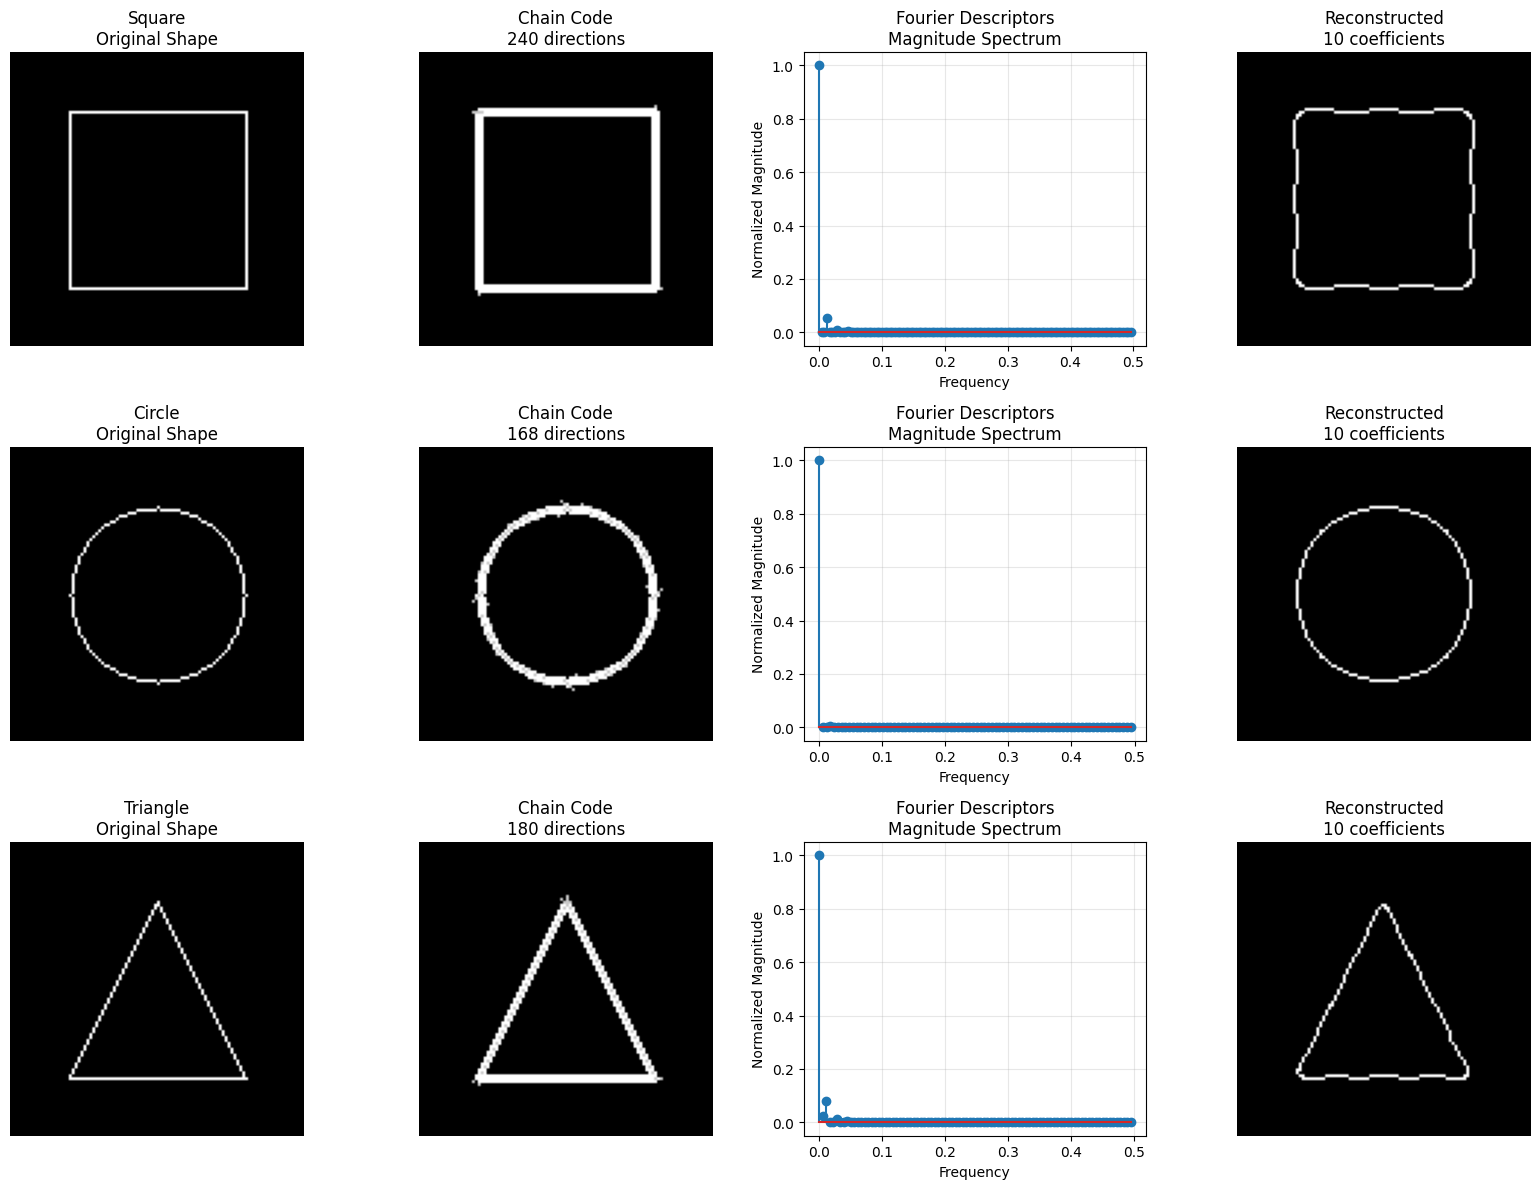

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def latihan_2():
    # Buat bentuk sederhana untuk analisis boundary
    shapes = []

    # 1. Persegi (untuk chain code sederhana)
    square = np.zeros((100, 100), dtype=np.uint8)
    cv2.rectangle(square, (20, 20), (80, 80), 255, 1)
    shapes.append(('Square', square))

    # 2. Lingkaran
    circle = np.zeros((100, 100), dtype=np.uint8)
    cv2.circle(circle, (50, 50), 30, 255, 1)
    shapes.append(('Circle', circle))

    # 3. Segitiga
    triangle = np.zeros((100, 100), dtype=np.uint8)
    pts = np.array([[50, 20], [20, 80], [80, 80]])
    cv2.polylines(triangle, [pts], True, 255, 1)
    shapes.append(('Triangle', triangle))

    # =========================
    # FUNCTION DIPINDAHKAN
    # =========================

    def freeman_chain_code_8dir(points):
        """Calculate 8-directional Freeman chain code"""
        if len(points) < 2:
            return []

        directions_8 = [
            (1, 0),   # 0: East
            (1, 1),   # 1: Southeast
            (0, 1),   # 2: South
            (-1, 1),  # 3: Southwest
            (-1, 0),  # 4: West
            (-1, -1), # 5: Northwest
            (0, -1),  # 6: North
            (1, -1)   # 7: Northeast
        ]

        chain_code = []

        for i in range(len(points)):
            current = points[i]
            next_point = points[(i + 1) % len(points)]

            dx = next_point[0] - current[0]
            dy = next_point[1] - current[1]

            dx = np.sign(dx)
            dy = np.sign(dy)

            for dir_code, (dir_dx, dir_dy) in enumerate(directions_8):
                if dx == dir_dx and dy == dir_dy:
                    chain_code.append(dir_code)
                    break

        return chain_code

    def compute_fourier_descriptors(points):
        """Compute Fourier descriptors from boundary points"""

        points = np.array(points)

        z = points[:, 0] + 1j * points[:, 1]

        fd = np.fft.fft(z)

        fd_magnitude = np.abs(fd)

        if fd_magnitude[0] != 0:
            fd_normalized = fd_magnitude / fd_magnitude[0]
        else:
            fd_normalized = fd_magnitude

        return fd, fd_normalized

    def reconstruct_shape(fd, num_coeffs):
        """Reconstruct shape using limited Fourier coefficients"""

        fd_recon = np.zeros_like(fd)

        fd_recon[:num_coeffs] = fd[:num_coeffs]
        fd_recon[-num_coeffs:] = fd[-num_coeffs:]

        z_recon = np.fft.ifft(fd_recon)

        return z_recon.real, z_recon.imag

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))

    for row, (name, shape) in enumerate(shapes):

        contours, _ = cv2.findContours(
            shape,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_NONE
        )

        contour = contours[0]

        contour_simple = []

        for i in range(len(contour)):
            if i == 0 or not np.array_equal(contour[i][0], contour[i-1][0]):
                contour_simple.append(contour[i][0])

        contour_simple = np.array(contour_simple)

        # 1. Original shape
        axes[row, 0].imshow(shape, cmap='gray')
        axes[row, 0].set_title(f'{name}\nOriginal Shape')
        axes[row, 0].axis('off')

        # 2. Chain Code
        chain_code = freeman_chain_code_8dir(contour_simple)

        chain_display = np.zeros((100, 100), dtype=np.uint8)

        for i, point in enumerate(contour_simple):

            cv2.circle(
                chain_display,
                tuple(point.astype(int)),
                1,
                255,
                -1
            )

            if i < len(chain_code):

                dir_code = chain_code[i]

                directions = [
                    (1,0), (1,1), (0,1), (-1,1),
                    (-1,0), (-1,-1), (0,-1), (1,-1)
                ]

                dx, dy = directions[dir_code]

                end_point = (
                    int(point[0] + dx*3),
                    int(point[1] + dy*3)
                )

                cv2.arrowedLine(
                    chain_display,
                    tuple(point.astype(int)),
                    end_point,
                    200,
                    1
                )

        axes[row, 1].imshow(chain_display, cmap='gray')
        axes[row, 1].set_title(f'Chain Code\n{len(chain_code)} directions')
        axes[row, 1].axis('off')

        # 3. Fourier Descriptor
        if len(contour_simple) > 10:

            num_samples = min(256, len(contour_simple))

            indices = np.linspace(
                0,
                len(contour_simple)-1,
                num_samples
            ).astype(int)

            sampled_points = contour_simple[indices]

            fd, fd_norm = compute_fourier_descriptors(sampled_points)

            n = len(fd_norm)

            frequencies = np.fft.fftfreq(n)

            axes[row, 2].stem(
                frequencies[:n//2],
                fd_norm[:n//2]
            )

            axes[row, 2].set_title(
                'Fourier Descriptors\nMagnitude Spectrum'
            )

            axes[row, 2].set_xlabel('Frequency')
            axes[row, 2].set_ylabel('Normalized Magnitude')
            axes[row, 2].grid(True, alpha=0.3)

            # 4. Reconstruction
            x_recon, y_recon = reconstruct_shape(fd, 10)

            recon_img = np.zeros((100, 100), dtype=np.uint8)

            points_recon = np.column_stack([
                x_recon.astype(int),
                y_recon.astype(int)
            ])

            for i in range(len(points_recon)):

                start_point = tuple(points_recon[i])
                end_point = tuple(
                    points_recon[(i + 1) % len(points_recon)]
                )

                if (
                    0 <= start_point[0] < 100 and
                    0 <= start_point[1] < 100 and
                    0 <= end_point[0] < 100 and
                    0 <= end_point[1] < 100
                ):
                    cv2.line(
                        recon_img,
                        start_point,
                        end_point,
                        255,
                        1
                    )

            axes[row, 3].imshow(recon_img, cmap='gray')
            axes[row, 3].set_title(
                'Reconstructed\n10 coefficients'
            )

            axes[row, 3].axis('off')

        else:

            axes[row, 2].text(
                0.5,
                0.5,
                'Not enough points\nfor Fourier analysis',
                ha='center',
                va='center',
                transform=axes[row, 2].transAxes
            )

            axes[row, 2].axis('off')
            axes[row, 3].axis('off')

    plt.tight_layout()
    plt.show()

# Jalankan
latihan_2()